(2400, 306) (600, 306)
Canonical_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 8
)
INITIALIZATION COMPLETE
(3000, 102, 3)
(3000, 306)
Perturbed Latents Shape: (600, 8)


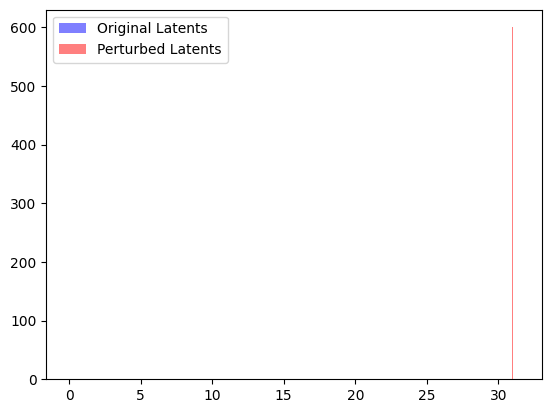

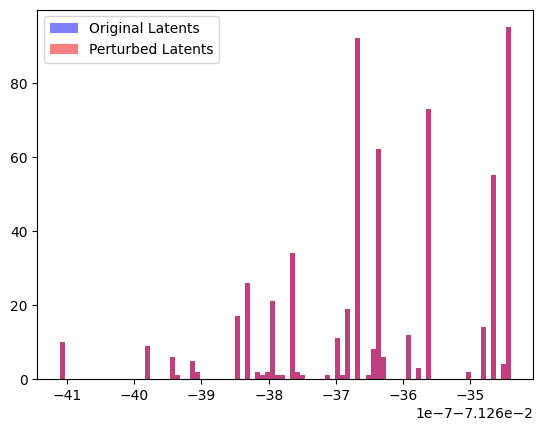

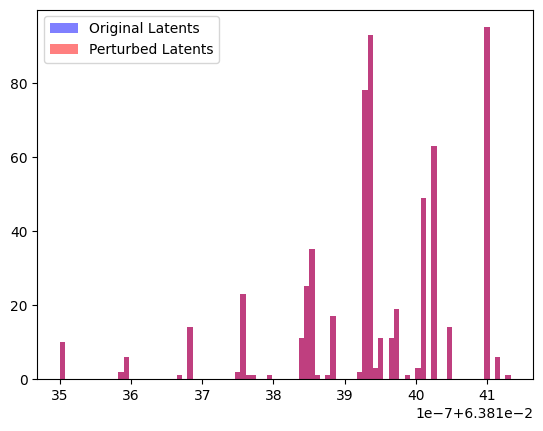

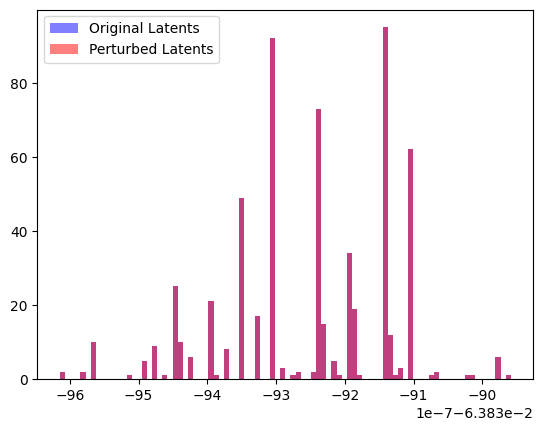

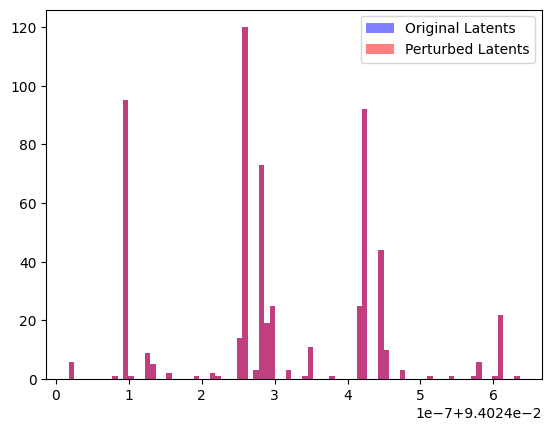

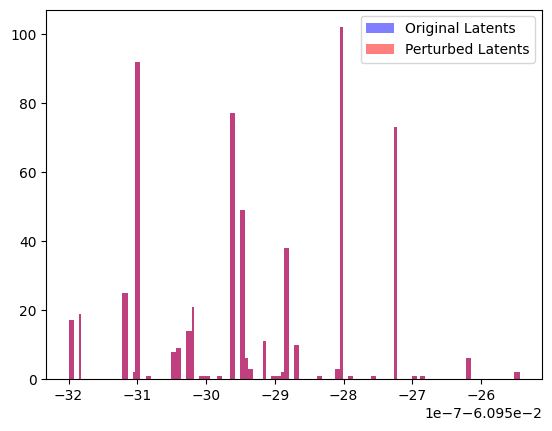

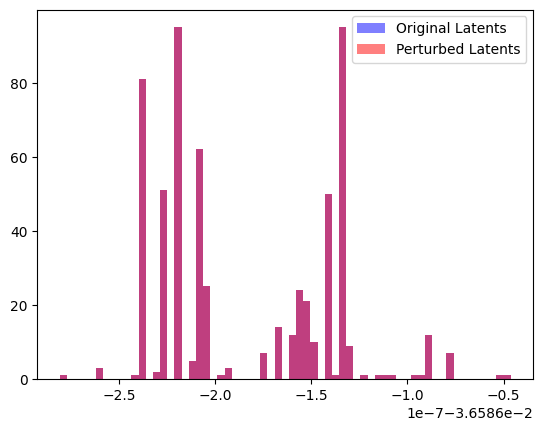

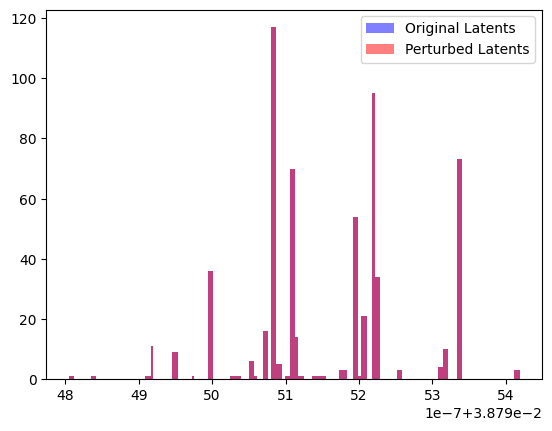

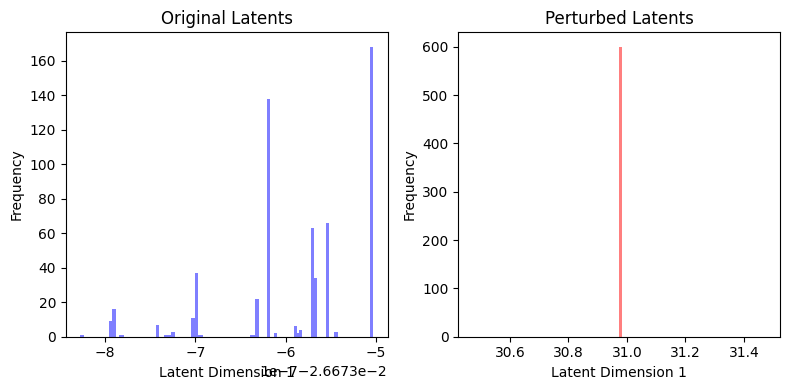

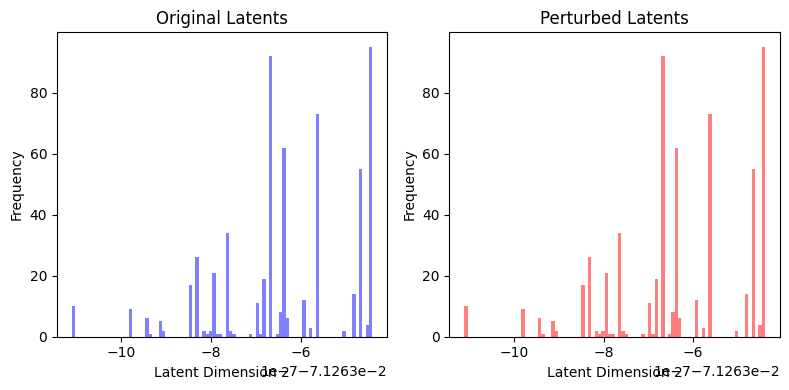

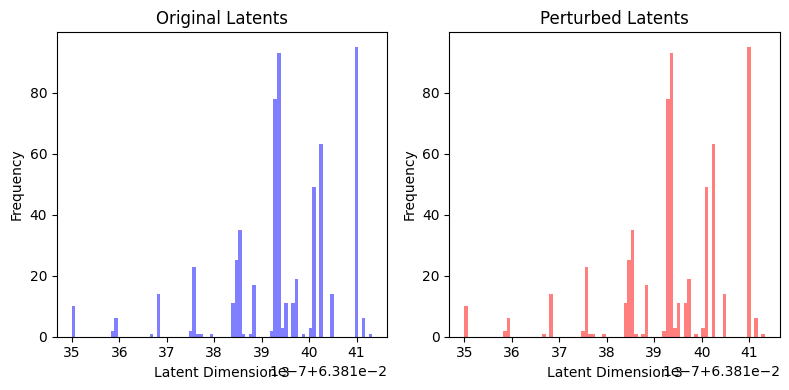

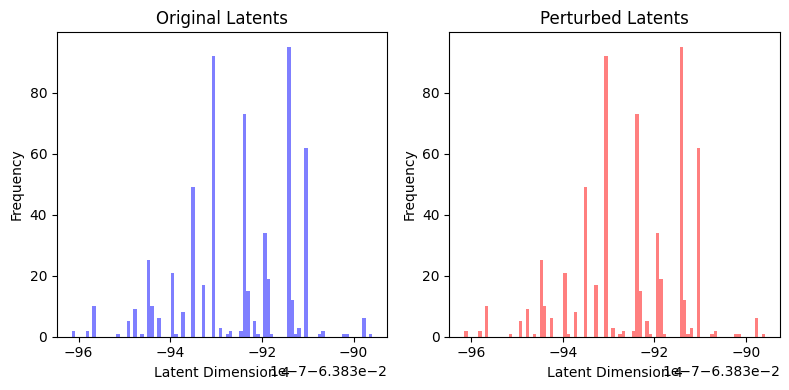

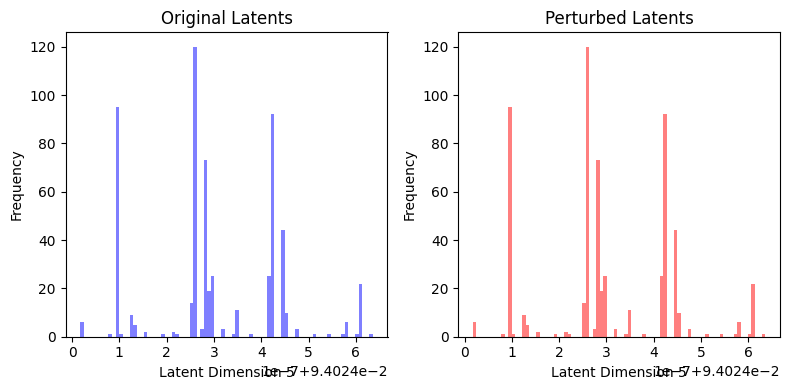

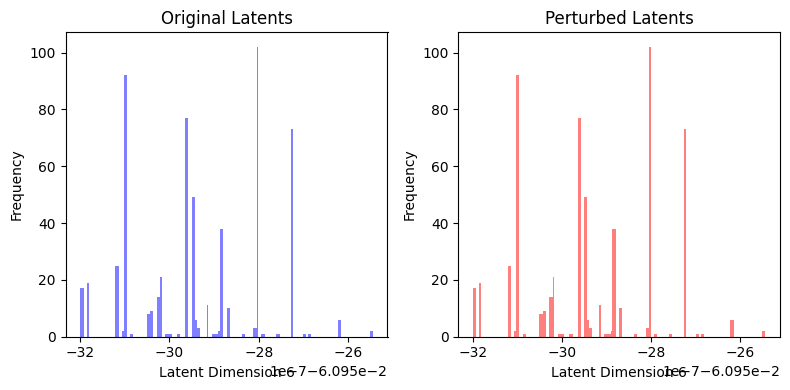

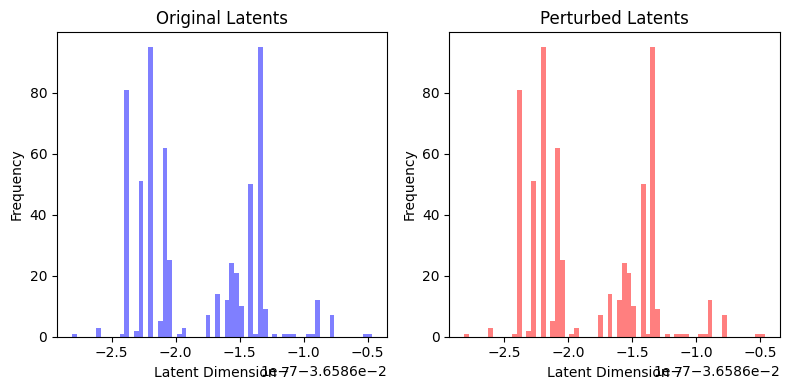

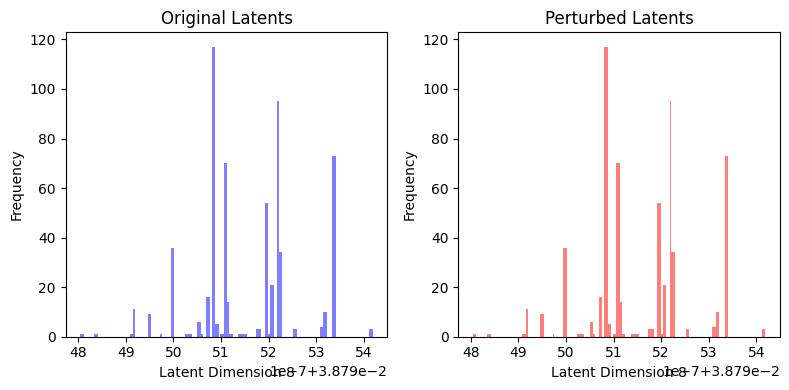

In [2]:
import Canonical_AutoEncoder_Experiment
import sys
import jax
import mdtraj as md
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Configure JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)

# JSON configuration file path
json_fn = "/media/volume/sdb/Timooo/Auto_Encoding_FE/AE_TEST_SMALL_08_3.json"

# Initialize the experiment
experiment = Canonical_AutoEncoder_Experiment.NN_Experiment(json_fn)

# Loading the model checkpoint
ckpt_fn = "model_ckpt_005000.pkl"
experiment.load_model_from_ckpt(ckpt_fn)

# Save testing data as a trajectory
experiment.write_traj("test_data", experiment.test_data)

# Load simulation data
c = md.load('/media/volume/sdb/Timooo/Auto_Encoding_FE/Simulation/small_test.dcd', top='/media/volume/sdb/Timooo/Auto_Encoding_FE/Simulation/ala_deca_peptide.prmtop')
coords = jnp.array(c.superpose(c).xyz)
print(coords.shape)

# Flatten the dimensions
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)

# Encode the test data, obtaining both decoded and latent representations
recon = experiment.state.apply_fn({'params': experiment.state.params}, experiment.test_data)
decoded_data = recon[0]
original_latents = recon[1]

# Perturb Latent Representations
perturbed_latents = jnp.array(original_latents)  # Copy original latents
perturbed_latents = perturbed_latents.at[:, 0].add(31)  # Perturb the first column

# Print the shape of the perturbed latents
print("Perturbed Latents Shape:", perturbed_latents.shape)

# Visualize original latents and perturbed latents
for i in range(original_latents.shape[1]):
    _ = plt.hist(original_latents[:, i], bins=100, color='blue', alpha=0.5, label='Original Latents')
    _ = plt.hist(perturbed_latents[:, i], bins=100, color='red', alpha=0.5, label='Perturbed Latents')
    plt.legend()
    plt.show()

# Plot histograms and analysis model to compare original and perturbed latents
def compare_latents(original_latents, perturbed_latents):
    for i in range(original_latents.shape[1]):
        plt.figure(figsize=(8, 4))

        # Original Latents Histogram
        plt.subplot(1, 2, 1)
        plt.hist(original_latents[:, i], bins=100, color='blue', alpha=0.5)
        plt.xlabel(f'Latent Dimension {i + 1}')
        plt.ylabel('Frequency')
        plt.title('Original Latents')

        # Perturbed Latents Histogram
        plt.subplot(1, 2, 2)
        plt.hist(perturbed_latents[:, i], bins=100, color='red', alpha=0.5)
        plt.xlabel(f'Latent Dimension {i + 1}')
        plt.ylabel('Frequency')
        plt.title('Perturbed Latents')

        plt.tight_layout()
        plt.show()

    
# Compare original and perturbed latents
compare_latents(original_latents, perturbed_latents)


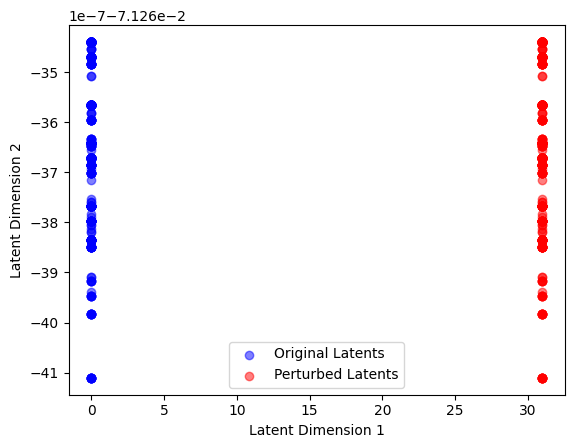

In [6]:
# Example: Scatter Plot
plt.scatter(original_latents[:, 0], original_latents[:, 1], label='Original Latents', c='blue', alpha=0.5)
plt.scatter(perturbed_latents[:, 0], perturbed_latents[:, 1], label='Perturbed Latents', c='red', alpha=0.5)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.legend()
plt.show()



In [8]:
!pip install scikit-learn



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 112.6 MB/s eta 0:00:0000:010:01


In [13]:
# Example: Pearson Correlation with Handling of Constant Columns
def calculate_pearson_correlation(data):
    # Check for constant columns and remove them
    std_dev = np.std(data, axis=0)
    constant_columns = np.where(std_dev == 0)[0]

    # Remove constant columns
    data_filtered = np.delete(data, constant_columns, axis=1)

    # Calculate Pearson correlation on filtered data
    correlation_matrix = np.corrcoef(data_filtered, rowvar=False)
    
    return correlation_matrix

# Calculate Pearson correlation for original and perturbed latents
correlation_matrix_original = calculate_pearson_correlation(original_latents)
correlation_matrix_perturbed = calculate_pearson_correlation(perturbed_latents)

# Handle any remaining NaN or infinity values in the correlation matrices if needed
correlation_matrix_original = np.nan_to_num(correlation_matrix_original)
correlation_matrix_perturbed = np.nan_to_num(correlation_matrix_perturbed)




In [17]:
pip install seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 8.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


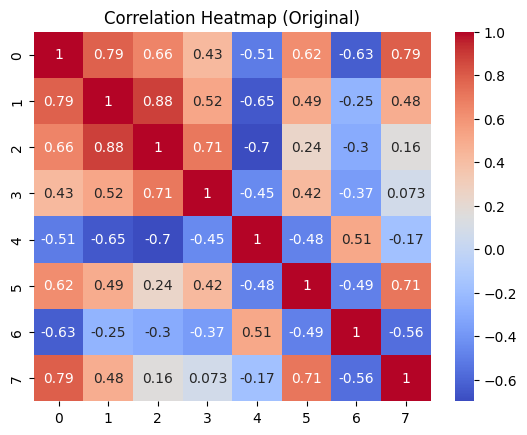

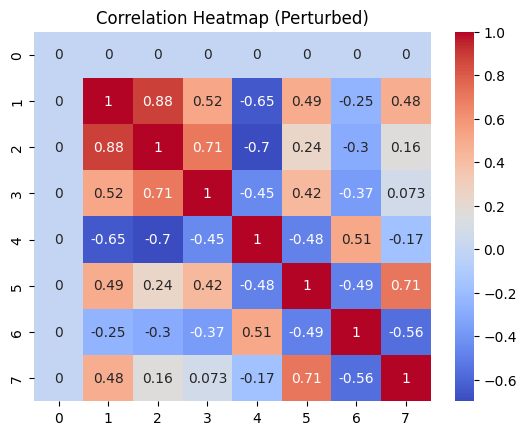

In [18]:
# Example: Heatmap
import seaborn as sns

# Create correlation matrices (as calculated earlier)
sns.heatmap(correlation_matrix_original, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Original)")
plt.show()

sns.heatmap(correlation_matrix_perturbed, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Perturbed)")
plt.show()


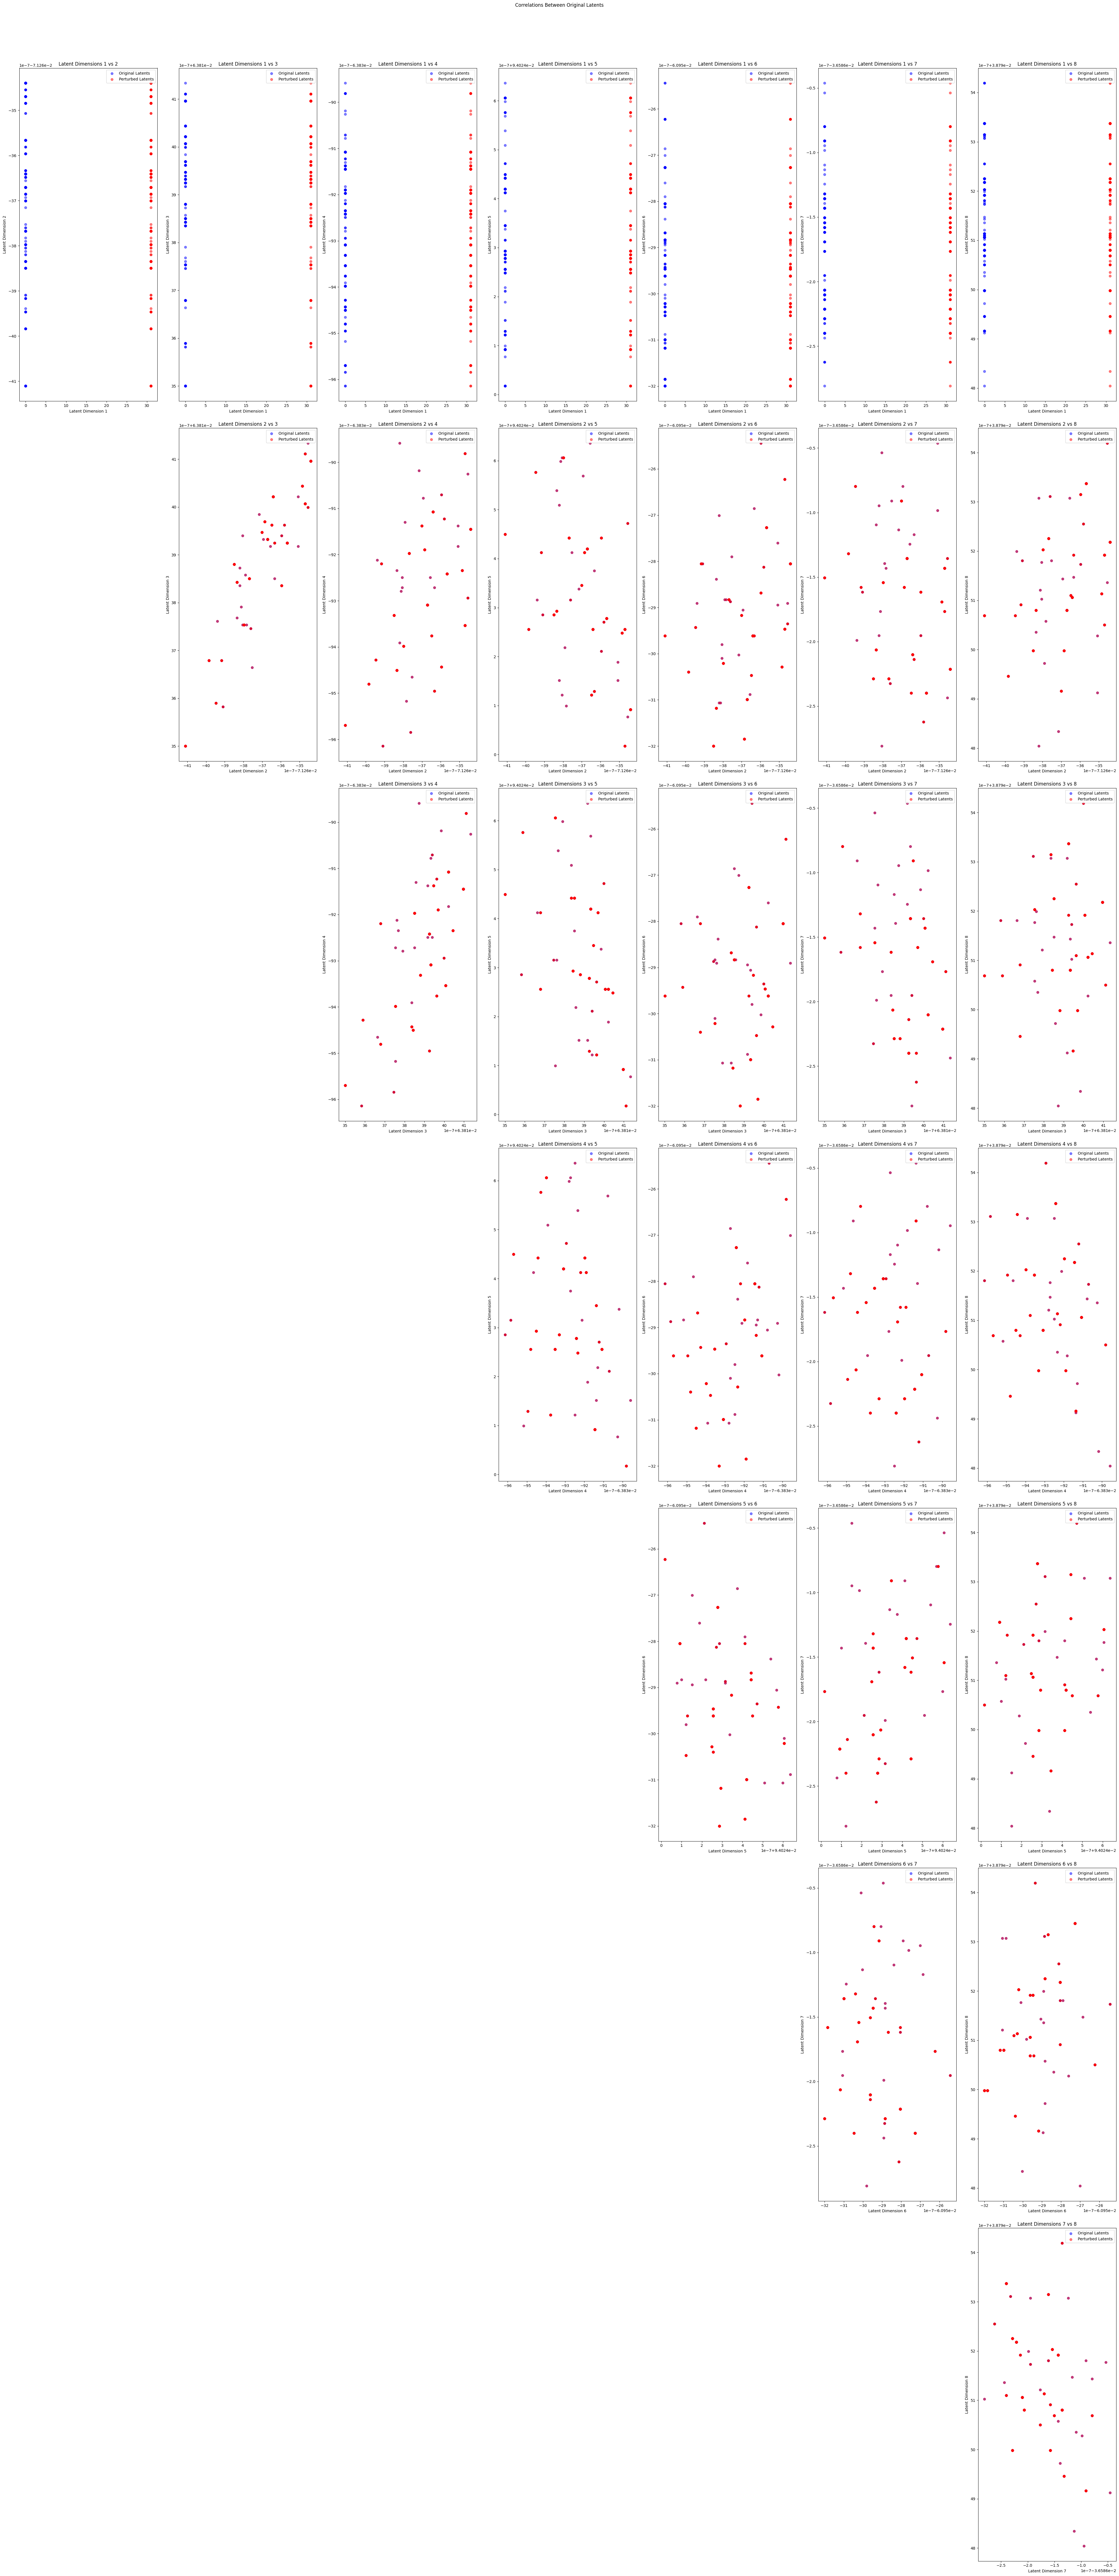

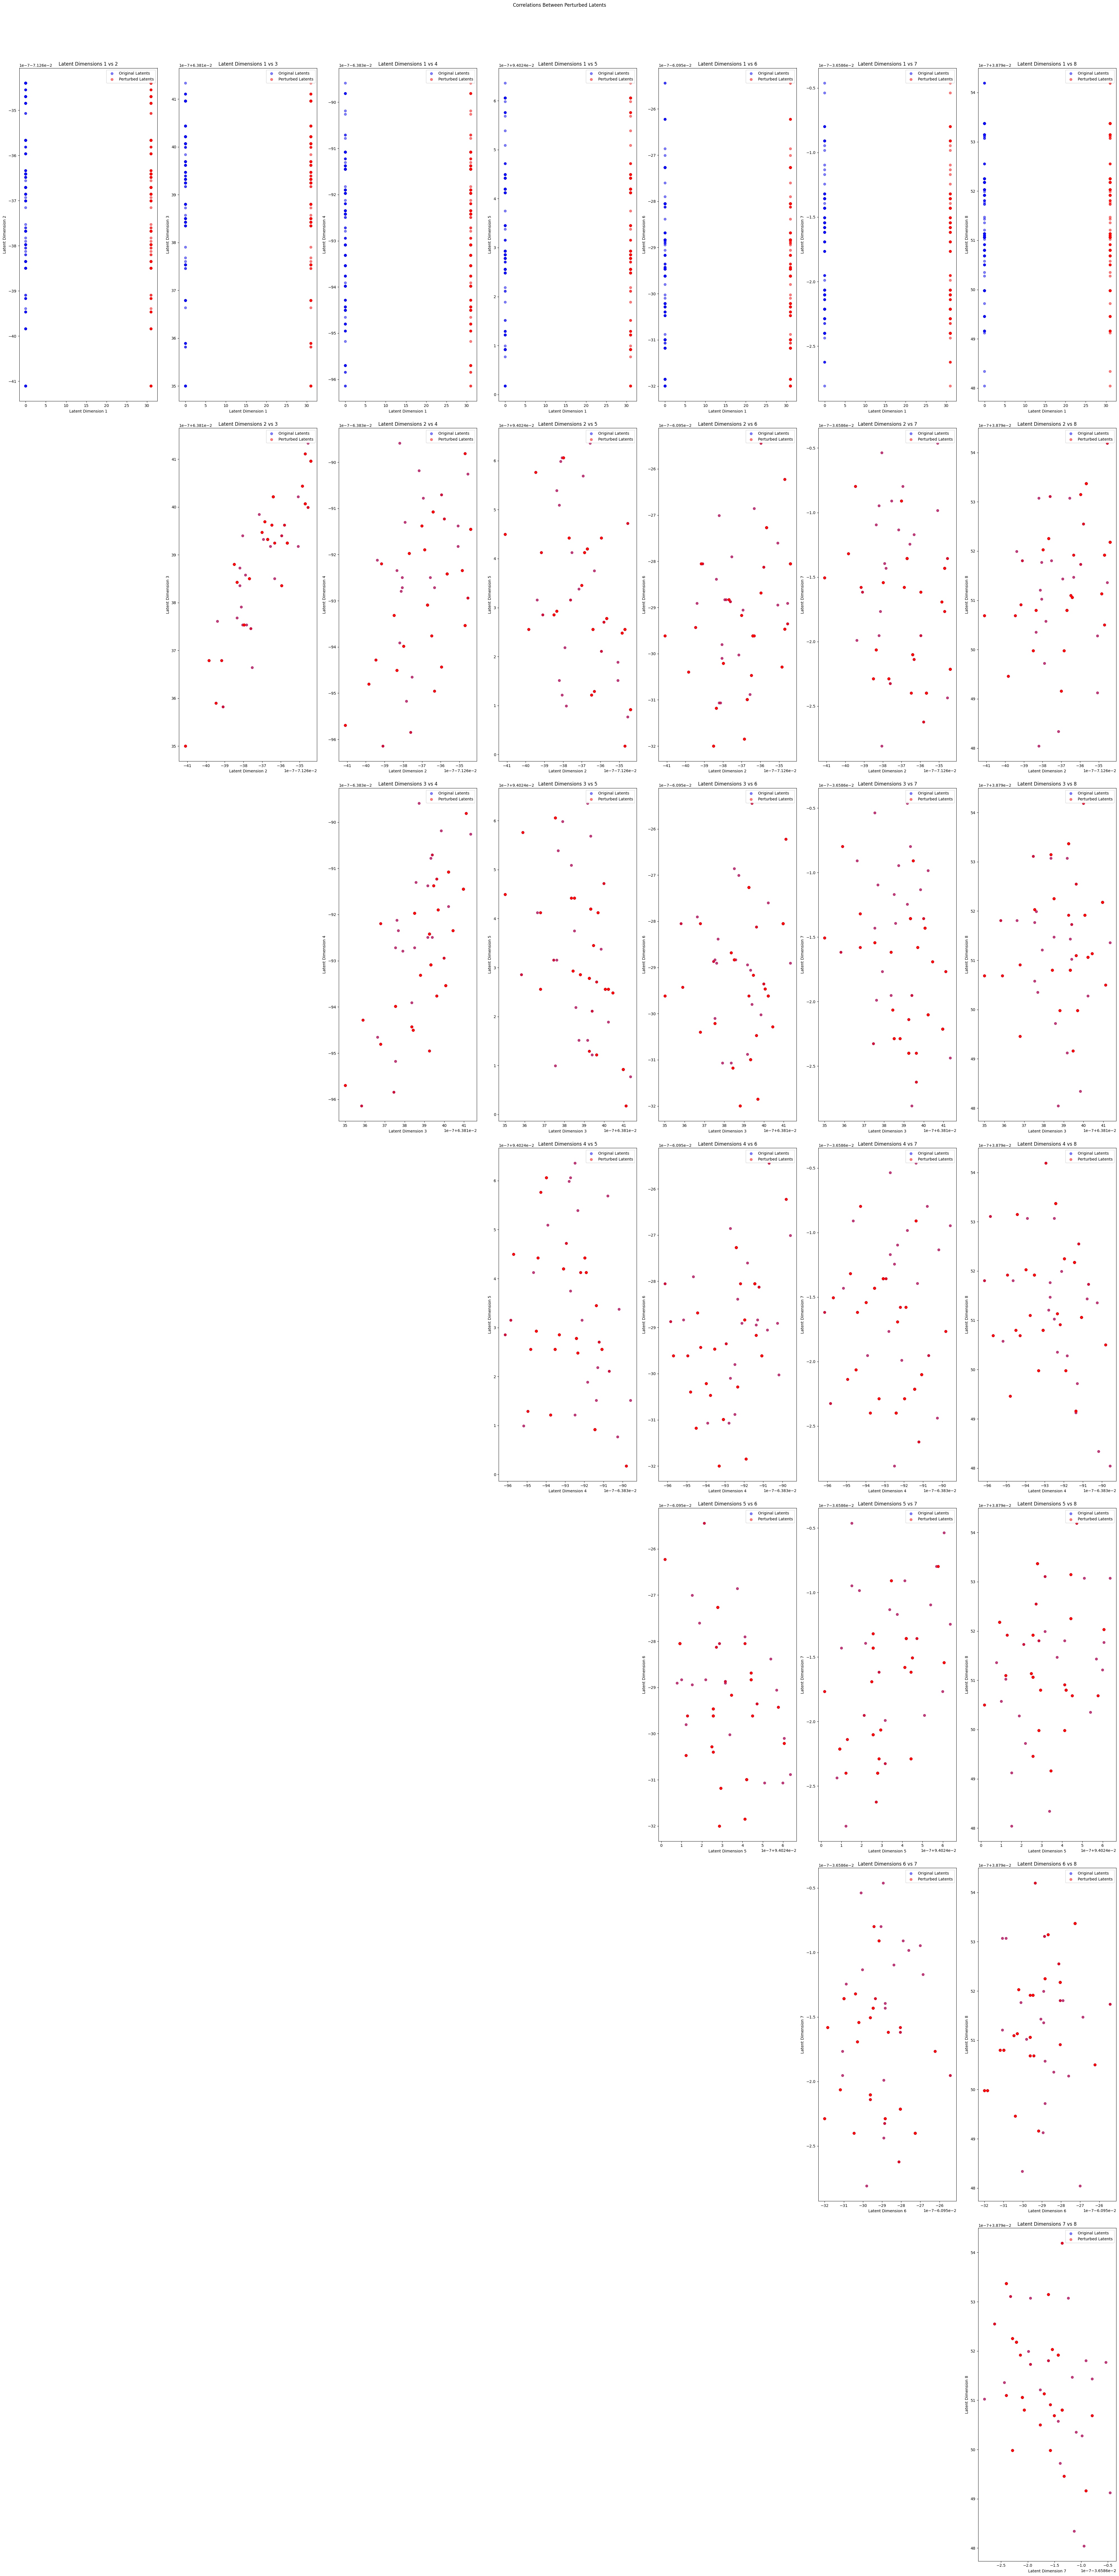

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Define the calculate_pearson_correlation function
def calculate_pearson_correlation(data):
    # Check for constant columns and remove them
    std_dev = np.std(data, axis=0)
    constant_columns = np.where(std_dev == 0)[0]

    # Remove constant columns
    data_filtered = np.delete(data, constant_columns, axis=1)

    # Calculate Pearson correlation on filtered data
    correlation_matrix = np.corrcoef(data_filtered, rowvar=False)
    
    return correlation_matrix

# Calculate Pearson correlation for original and perturbed latents
correlation_matrix_original = calculate_pearson_correlation(original_latents)
correlation_matrix_perturbed = calculate_pearson_correlation(perturbed_latents)

# Create scatter plots for each dimension
def scatterplot_correlations(correlation_matrix, title):
    num_dimensions = correlation_matrix.shape[0]

    # Create a new figure for the scatter plots
    plt.figure(figsize=(40,90))

    for i in range(num_dimensions):
        for j in range(i + 1, num_dimensions):
            plt.subplot(num_dimensions - 1, num_dimensions - 1, i * (num_dimensions - 1) + j)

            # Scatter plot
            plt.scatter(original_latents[:, i], original_latents[:, j], color='blue', label='Original Latents', alpha=0.5)
            plt.scatter(perturbed_latents[:, i], perturbed_latents[:, j], color='red', label='Perturbed Latents', alpha=0.5)
            plt.xlabel(f'Latent Dimension {i + 1}')
            plt.ylabel(f'Latent Dimension {j + 1}')
            plt.title(f'Latent Dimensions {i + 1} vs {j + 1}')
            plt.legend()

    plt.tight_layout()
    plt.suptitle(title, y=1.02)
    plt.show()

# Create scatter plots for original and perturbed latents
scatterplot_correlations(correlation_matrix_original, "Correlations Between Original Latents")
scatterplot_correlations(correlation_matrix_perturbed, "Correlations Between Perturbed Latents")



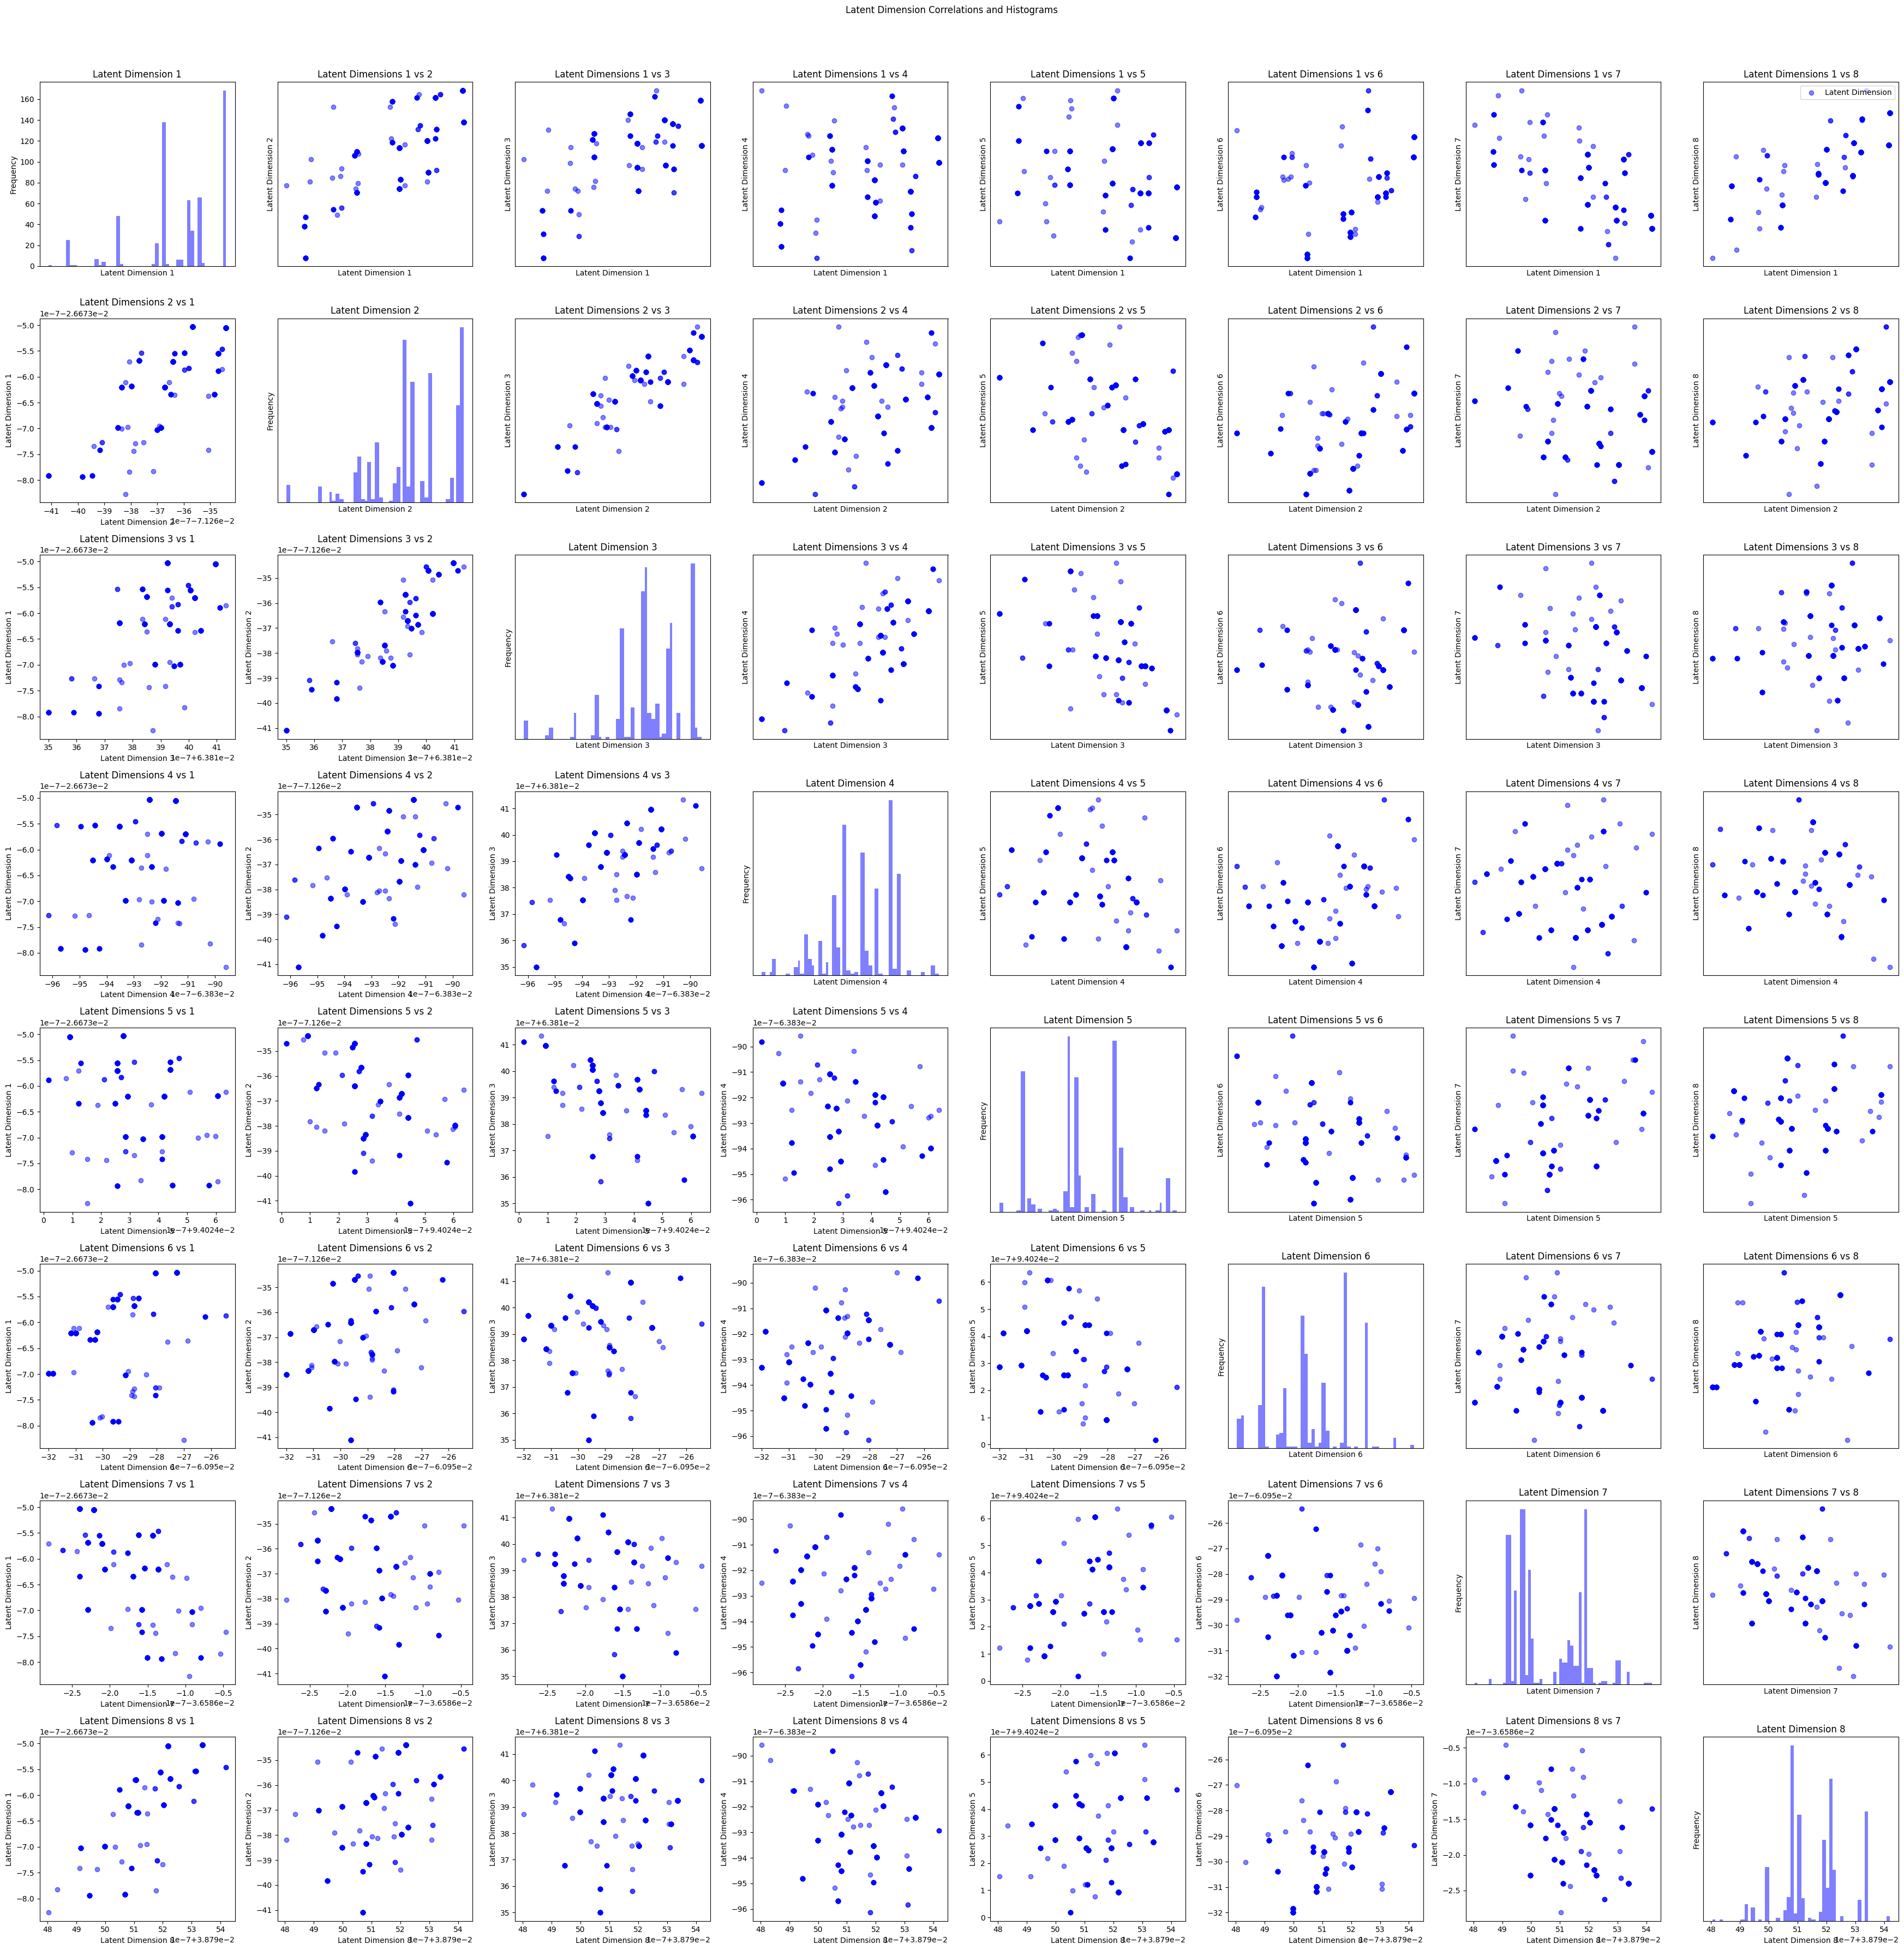

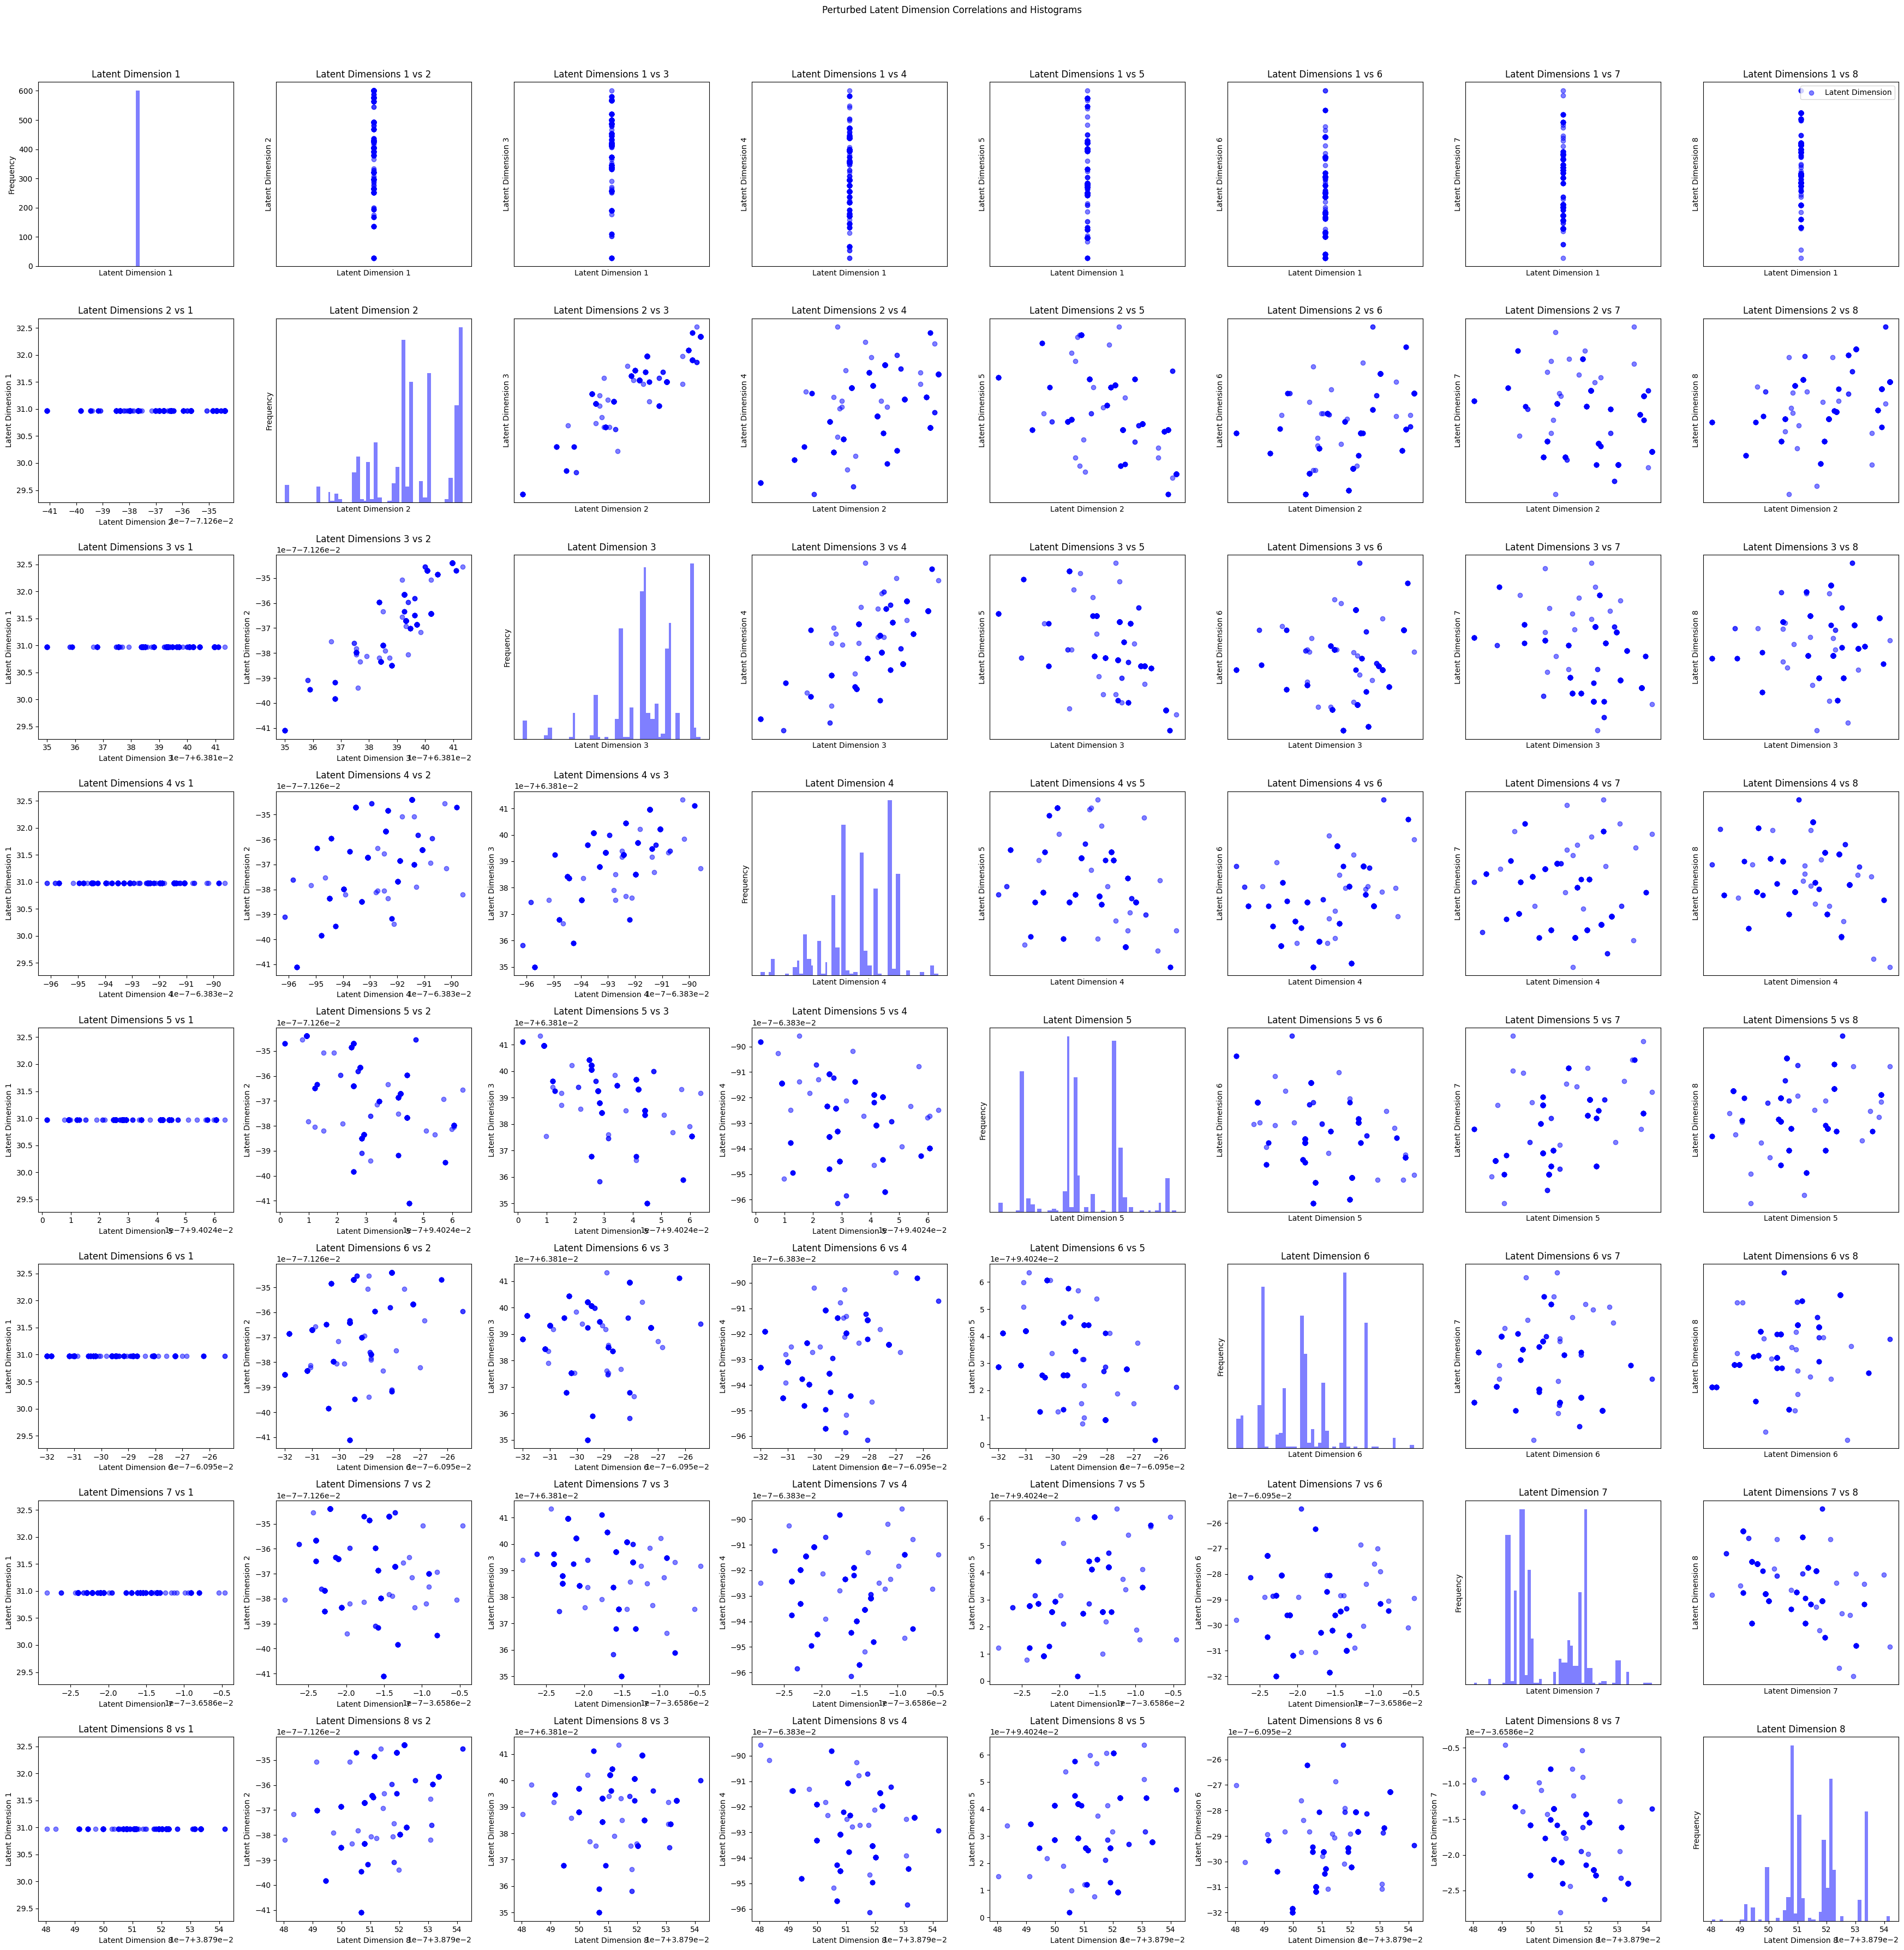

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def scatterplot_histograms(latents, title):
    num_dimensions = latents.shape[1]

    # Create a new figure for the scatter plots and histograms
    fig, axes = plt.subplots(num_dimensions, num_dimensions, figsize=(35, 35))  # Update the figsize

    for i in range(num_dimensions):
        for j in range(i, num_dimensions):
            if i == j:
                # Create histograms on the diagonal
                axes[i, j].hist(latents[:, i], bins=50, color='blue', alpha=0.5, label='Latent Dimension')
                axes[i, j].set_xlabel(f'Latent Dimension {i + 1}')
                axes[i, j].set_ylabel('Frequency')
                axes[i, j].set_title(f'Latent Dimension {i + 1}')

            else:
                # Create scatter plots off-diagonal
                axes[i, j].scatter(latents[:, i], latents[:, j], color='blue', alpha=0.5, label='Latent Dimension')
                axes[i, j].set_xlabel(f'Latent Dimension {i + 1}')
                axes[i, j].set_ylabel(f'Latent Dimension {j + 1}')
                axes[i, j].set_title(f'Latent Dimensions {i + 1} vs {j + 1}')

            # Remove x and y ticks for plots not on the edges
            if i < num_dimensions - 1:
                axes[i, j].set_xticks([])
            if j > 0:
                axes[i, j].set_yticks([])

            # Invert the scatter plot layout
            if i != j:
                axes[j, i].scatter(latents[:, j], latents[:, i], color='blue', alpha=0.5, label='Latent Dimension')
                axes[j, i].set_xlabel(f'Latent Dimension {j + 1}')
                axes[j, i].set_ylabel(f'Latent Dimension {i + 1}')
                axes[j, i].set_title(f'Latent Dimensions {j + 1} vs {i + 1}')

    # Set the title for the entire plot
    fig.suptitle(title, y=1.02)

    # Display the legend in the last subplot
    axes[0, num_dimensions - 1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Usage: Call this function with the latents you want to visualize
scatterplot_histograms(original_latents, "Latent Dimension Correlations and Histograms")
scatterplot_histograms(perturbed_latents, "Perturbed Latent Dimension Correlations and Histograms")


